In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML

In [73]:
df_uncleaned = pd.read_csv('../Datasets/amazon_products_sales_data_uncleaned.csv')
df_uncleaned.head(1)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29


In [ ]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df_uncleaned)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,37546,0,object,7719
1,product_rating,0,37546,float64,1
2,total_reviews,0,37546,float64,1
3,purchased_last_month,0,37546,float64,1
4,original_price,37546,0,float64,3136
5,is_sponsored,37546,0,int64,2
6,coupon,37546,0,object,42
7,buy_box_availability,37546,0,int64,2
8,sustainability_tags,37546,0,int64,2
9,product_image_url,37546,0,object,7618


# DUPLICADOS
### Primero estudiamos qué tipo de duplicados hay

In [75]:
clean = pd.read_csv('../Datasets/amazon_final.csv')
clean.head(1)

,product_title,product_rating,total_reviews,purchased_last_month,original_price,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,...,badge_ends_in,badge_limited_time_deal,badge_no_badge,badge_save_xpct,product_category,product_segment,log_original_price,segment_Alta/Premium,segment_Baja,segment_Media
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,NaN,NaN,NaN,159.0,1,Save 15% with coupon,1,1,https://m.media-amazon.com/images/I/71pAqiVEs3...,...,0,0,1,0,"Audio, Sound & Recording Gear",Media,5.075174,0,0,1


In [76]:
dfcopia = df_uncleaned.copy()
dfcopia.drop(columns=['collected_at'], inplace= True)


In [77]:
# Opción 1: Duplicados exactos (probablemente 0, como mencionaste)
num_duplicados_exactos = df_uncleaned.duplicated().sum()
print(f"Duplicados exactos (todas las columnas iguales): {num_duplicados_exactos}")

# Opción 2: Duplicados IGNORANDO la fecha de recolección (Lo que seguramente buscas)
# Esto te dice cuántas filas son idénticas en datos, variando solo el momento del scrapeo.
cols_sin_fecha = [col for col in df_uncleaned.columns if col != 'collected_at']
num_duplicados_data = df_uncleaned.duplicated(subset=cols_sin_fecha).sum()
print(f"Duplicados de contenido (ignorando fecha): {num_duplicados_data}")

# Opción 3: Cuántos registros repetidos de PRODUCTO hay (basado en Título)
# Esto te dice cuántas veces has scrapeado los mismos productos, aunque el precio haya cambiado.
num_duplicados_producto = df_uncleaned.duplicated(subset=['title']).sum()
print(f"Registros repetidos por Título de producto: {num_duplicados_producto}")

Duplicados exactos (todas las columnas iguales): 0
Duplicados de contenido (ignorando fecha): 1815
Registros repetidos por Título de producto: 33867


In [78]:
# Ver las filas duplicadas (ignorando fecha) para inspeccionarlas
duplicados_view = dfcopia[dfcopia.duplicated(subset=cols_sin_fecha, keep=False)]
duplicados_view.sort_values(by='title').head(1)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url
10759,12-Pack Duracell 2450 Batteries 3.0 Volt Lithi...,4.8 out of 5 stars,"1,289",300+ bought in past month,NaN,basic variant price: 1 Count (Pack of 12),No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/71-ldBrQYQ...,NaN


In [79]:
# 1. Identificamos las columnas que NO son fecha ni título (las que pueden variar)
cols_analisis = [c for c in df_uncleaned.columns if c not in ['collected_at', 'title']]

# 2. Agrupamos por título y contamos cuántos valores ÚNICOS hay en cada columna
# Si un producto tiene 1 valor único en 'price', es que nunca cambió de precio.
# Si tiene 2 o más, es que hubo cambios.
variabilidad = df_uncleaned.groupby('title')[cols_analisis].nunique()

# 3. Filtramos solo los productos que han sufrido cambios (alguna columna con > 1 valor)
productos_con_cambios = variabilidad[variabilidad > 1].dropna(how='all')

print(f"Productos únicos que han cambiado en el tiempo: {len(productos_con_cambios)}")
print("\n¿Qué columnas cambian más frecuentemente? (Top variaciones):")
# Esto suma cuántas veces cada columna fue la que cambió
print((productos_con_cambios > 1).sum().sort_values(ascending=False))

Productos únicos que han cambiado en el tiempo: 1065

¿Qué columnas cambian más frecuentemente? (Top variaciones):
product_url                 1048
delivery_details             558
number_of_reviews            230
price_on_variant             192
is_best_seller               162
current/discounted_price     103
is_sponsored                  93
bought_in_last_month          70
listed_price                  56
rating                        44
image_url                     17
is_couponed                    5
buy_box_availability           0
sustainability_badges          0
dtype: int64


In [80]:
# Buscamos el título del producto que más cambios ha tenido (suma de variaciones)
titulo_mas_cambiante = variabilidad.sum(axis=1).idxmax()

print(f"Ejemplo de producto cambiante: {titulo_mas_cambiante}")

# Mostramos sus datos ordenados por fecha para ver la evolución
cols_ver = ['collected_at', 'current/discounted_price', 'rating', 'number_of_reviews', 'buy_box_availability']
historia_producto = df_uncleaned[df_uncleaned['title'] == titulo_mas_cambiante][cols_ver].sort_values('collected_at')

historia_producto

Ejemplo de producto cambiante: TRX Training 6 Month On-Demand Membership - Unlimited Access to Expert-Led Workouts, Personalized Programs, Strength, Cardio & Recovery - Train Anytime


,collected_at,current/discounted_price,rating,number_of_reviews,buy_box_availability
777,2025-08-21 11:20:48,49.95,4.7 out of 5 stars,8,Add to cart
810,2025-08-21 11:20:59,49.95,4.7 out of 5 stars,8,Add to cart
839,2025-08-21 11:21:25,49.95,4.7 out of 5 stars,8,Add to cart
887,2025-08-21 11:21:52,49.95,4.7 out of 5 stars,8,Add to cart
920,2025-08-21 11:22:03,49.95,4.7 out of 5 stars,8,Add to cart
...,...,...,...,...,...
41987,2025-08-30 19:49:57,49.95,4.7 out of 5 stars,8,Add to cart
42029,2025-08-30 19:50:20,49.95,4.7 out of 5 stars,8,Add to cart
42295,2025-08-30 19:52:32,49.95,4.7 out of 5 stars,8,Add to cart
42423,2025-08-30 19:53:37,49.95,4.7 out of 5 stars,8,Add to cart


In [81]:
# 1. Definimos las columnas que no son fecha (donde buscamos diferencias)
cols_sin_fecha = [c for c in df_uncleaned.columns if c != 'collected_at']

# 2. Elige un producto específico (pon aquí el título que te está dando 2 duplicados)
# Si no sabes cuál es, este código busca uno automático por ti:
conteo_variaciones = df_uncleaned.groupby('title')[cols_sin_fecha].apply(lambda x: x.drop_duplicates().shape[0])
producto_ejemplo = conteo_variaciones[conteo_variaciones == 2].index[3] 

print(f"Analizando producto: {producto_ejemplo}")

# 3. Obtenemos las filas de ese producto
df_producto = df_uncleaned[df_uncleaned['title'] == producto_ejemplo].copy()

# 4. Encontramos las filas únicas (ignorando fecha) y las transponemos para leerlas mejor
diferencias = df_producto.drop_duplicates(subset=cols_sin_fecha)

print("\n--- Comparativa de las 2 versiones del producto ---")
# Mostramos todas las columnas transponiendo la tabla
display(diferencias.T)

# 5. TRUCO PRO: Ver SOLO lo que cambia
# Esto filtra las columnas que son idénticas en ambas filas para dejarte solo las diferencias
columnas_diferentes = []
for col in cols_sin_fecha:
    if diferencias[col].nunique() > 1:
        columnas_diferentes.append(col)

print("\n--- ¡Aquí está la diferencia! ---")
display(diferencias[columnas_diferentes])

Analizando producto: 3M Gel Wrist Rest for Standing Desks, Wraps Around Edge of Desk for Comfort, Non-Slip Back Stays in Place (WR200B)

--- Comparativa de las 2 versiones del producto ---


,13755,13818
title,"3M Gel Wrist Rest for Standing Desks, Wraps Ar...","3M Gel Wrist Rest for Standing Desks, Wraps Ar..."
rating,4.1 out of 5 stars,4.1 out of 5 stars
number_of_reviews,410,410
bought_in_last_month,100+ bought in past month,100+ bought in past month
current/discounted_price,50.70,50.70
price_on_variant,basic variant price: $46.39,basic variant price: $46.39
listed_price,No Discount,No Discount
is_best_seller,No Badge,No Badge
is_sponsored,Organic,Organic
is_couponed,No Coupon,No Coupon



--- ¡Aquí está la diferencia! ---


,product_url
13755,/3M-Standing-Comfort-Non-Slip-WR200B/dp/B08N8J...
13818,/3M-Standing-Comfort-Non-Slip-WR200B/dp/B08N8J...


## NOS QUEDAMOS CON EL ÚLTIMO PRODUCTO SCRAPEADO DE CADA REPETICIÓN

In [82]:
# Ordenamos por fecha para asegurar que el 'last' es el más reciente
df_uncleaned = df_uncleaned.sort_values('collected_at')

# Eliminamos duplicados considerando 'title' (o ASIN si lo tienes) como la clave
# 'keep="last"' se queda con el scrapeo más reciente
df_uncleaned = df_uncleaned.drop_duplicates(subset=['title'], keep='last')

In [83]:
# Opción 1: Duplicados exactos (probablemente 0, como mencionaste)
num_duplicados_exactos = df_uncleaned.duplicated().sum()
print(f"Duplicados exactos (todas las columnas iguales): {num_duplicados_exactos}")

# Opción 2: Duplicados IGNORANDO la fecha de recolección (Lo que seguramente buscas)
# Esto te dice cuántas filas son idénticas en datos, variando solo el momento del scrapeo.
cols_sin_fecha = [col for col in df_uncleaned.columns if col != 'collected_at']
num_duplicados_data = df_uncleaned.duplicated(subset=cols_sin_fecha).sum()
print(f"Duplicados de contenido (ignorando fecha): {num_duplicados_data}")

# Opción 3: Cuántos registros repetidos de PRODUCTO hay (basado en Título)
# Esto te dice cuántas veces has scrapeado los mismos productos, aunque el precio haya cambiado.
num_duplicados_producto = df_uncleaned.duplicated(subset=['title']).sum()
print(f"Registros repetidos por Título de producto: {num_duplicados_producto}")

Duplicados exactos (todas las columnas iguales): 0
Duplicados de contenido (ignorando fecha): 0
Registros repetidos por Título de producto: 0


In [84]:
df_uncleaned[df_uncleaned['title'] == '3M Gel Wrist Rest for Standing Desks, Wraps Around Edge of Desk for Comfort, Non-Slip Back Stays in Place (WR200B)']

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
13818,"3M Gel Wrist Rest for Standing Desks, Wraps Ar...",4.1 out of 5 stars,410,100+ bought in past month,50.70,basic variant price: $46.39,No Discount,No Badge,Organic,No Coupon,Add to cart,"Delivery Tue, Sep 2",NaN,https://m.media-amazon.com/images/I/51eXPj3KRH...,/3M-Standing-Comfort-Non-Slip-WR200B/dp/B08N8J...,2025-08-24 22:21:28


## A continuación vamos a realizar el preprocesado de estos datos iniciales

### RATING

In [85]:
# Nos quedamos solo con los tres primeros caracteres de la columna 'rating' y los convertimos a float

df_uncleaned['rating'] = df_uncleaned.rating.str[0:3].astype(float)

### BOUGHT IN LAST MONTH

In [86]:
# Limpiamos la columna 'bought_in_last_month' eliminando el texto innecesario y convirtiendo 'K' a '000'

df_uncleaned['bought_in_last_month'] = df_uncleaned['bought_in_last_month'].str.replace("+ bought in past month","").str.strip().str.replace("K","000")

In [87]:
# Nos quedamos solo con los valores numéricos en 'bought_in_last_month'. Los non-numeric se convierten en NaN y luego convertimos la columna a tipo entero

df_uncleaned['bought_in_last_month'] = (
    df_uncleaned['bought_in_last_month']
    .where(df_uncleaned['bought_in_last_month'].str.isdigit(), np.nan)
    .astype('Int64')
)

In [88]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8808 entries, 32 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     8808 non-null   object 
 1   rating                    8743 non-null   float64
 2   number_of_reviews         8743 non-null   object 
 3   bought_in_last_month      7686 non-null   Int64  
 4   current/discounted_price  6005 non-null   object 
 5   price_on_variant          8808 non-null   object 
 6   listed_price              8808 non-null   object 
 7   is_best_seller            8808 non-null   object 
 8   is_sponsored              8808 non-null   object 
 9   is_couponed               8808 non-null   object 
 10  buy_box_availability      5547 non-null   object 
 11  delivery_details          5996 non-null   object 
 12  sustainability_badges     770 non-null    object 
 13  image_url                 8808 non-null   object 
 14  product_url

### PRICE_ON_VARIANT

Esta columna tiene errores en los textos, cogemos el valor tras ':' en aquellos que contienen el carácter dolar. Aquellos que no lo tengan, serán nulos

In [89]:
# Limpiamos la columna 'price_on_variant' para quedarnos solo con el valor numérico

df_uncleaned['price_on_variant'] = df_uncleaned['price_on_variant'].str.split(":").str.get(1)

In [90]:
# Nos quedamos solo con los valores que contienen el símbolo '$', los demás los convertimos en NaN

df_uncleaned.loc[~df_uncleaned['price_on_variant'].str.contains(r'\$', na=False), 'price_on_variant'] = np.nan

In [91]:
# Finalmente, eliminamos espacios y cualquier texto adicional después del valor numérico

df_uncleaned['price_on_variant'] = df_uncleaned['price_on_variant'].str.strip().str.split(" ").str.get(0)

### CURRENT/DISCOUNTED_PRICE

In [92]:
# Rellenamos los valores NaN en 'current/discounted_price' con los valores de 'price_on_variant'

df_uncleaned['current/discounted_price'] = df_uncleaned['current/discounted_price'].fillna(df_uncleaned['price_on_variant'])

In [93]:
# Convertimos las columnas de precios a tipo float después de eliminar el símbolo '$' y las comas

df_uncleaned['current/discounted_price'] = df_uncleaned['current/discounted_price'].str.replace(r"\$", "", regex=True).str.replace(r",", "").astype(float)

### LISTED_PRICE

In [94]:
# Limpiamos la columna 'listed_price' eliminando el símbolo '$' y las comas

df_uncleaned['listed_price'] = df_uncleaned['listed_price'].str.replace("$","").str.replace(",","").str.strip()

In [95]:
# Reemplazamos "No Discount" con NaN en la columna 'listed_price'

df_uncleaned['listed_price'].replace("No Discount", np.nan, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_20036\3967620138.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_uncleaned['listed_price'].replace("No Discount", np.nan, inplace=True)


In [96]:
# Rellenamos los valores NaN en 'listed_price' con los valores de 'current/discounted_price'

df_uncleaned['listed_price'].fillna(df_uncleaned['current/discounted_price'], inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_20036\206465943.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_uncleaned['listed_price'].fillna(df_uncleaned['current/discounted_price'], inplace=True)


In [97]:
df_uncleaned['listed_price'] = df_uncleaned['listed_price'].astype(float)

In [98]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8808 entries, 32 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     8808 non-null   object 
 1   rating                    8743 non-null   float64
 2   number_of_reviews         8743 non-null   object 
 3   bought_in_last_month      7686 non-null   Int64  
 4   current/discounted_price  8384 non-null   float64
 5   price_on_variant          5091 non-null   object 
 6   listed_price              8384 non-null   float64
 7   is_best_seller            8808 non-null   object 
 8   is_sponsored              8808 non-null   object 
 9   is_couponed               8808 non-null   object 
 10  buy_box_availability      5547 non-null   object 
 11  delivery_details          5996 non-null   object 
 12  sustainability_badges     770 non-null    object 
 13  image_url                 8808 non-null   object 
 14  product_url

### IS_COUPONED

#### Haremos dos características
- has_coupon : 0/1 
- is_couponed : valor del descuento (tenemos cupones con porcentajes y con valores de descuento)

In [99]:
# Creamos una nueva columna 'has_coupon' que indica con 1 si hay cupón y con 0 si no lo hay

df_uncleaned['has_coupon'] = np.where(df_uncleaned['is_couponed'] != 'No Coupon', 1, 0)
df_uncleaned.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,has_coupon
32,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358,<NA>,239.99,NaN,239.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/51vvx1JymA...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
31,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,276,<NA>,42.99,NaN,42.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/41d4RtiB8E...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
29,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,"101,072",50000,35.89,$35.89,35.89,Best Seller,Organic,No Coupon,NaN,NaN,Manufacturing practices,https://m.media-amazon.com/images/I/71y57XPIia...,/HP-Cartridge-Black-3YM57AN-Tri-Color/dp/B0841...,2025-08-21 11:14:29,0
28,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,"59,092",50000,43.89,$43.89,43.89,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/51eBahpKda...,/HP-Cartridges-Black-Tri-Color-3YP29AN/dp/B084...,2025-08-21 11:14:29,0
27,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,"108,926",10000,9.54,$9.54,9.54,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/41CiQ7hR31...,/Sony-MDRZX110-BLK-Stereo-Headphones/dp/B00NJ2...,2025-08-21 11:14:29,0


### BUY_BOX_AVAILABILITY
Convertimos la columna a binaria, 1 si tiene "Add to cart", 0 en caso contrario

In [100]:
df_uncleaned.buy_box_availability = np.where(df_uncleaned.buy_box_availability != "Add to cart", 0, 1)
df_uncleaned.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,has_coupon
32,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358,<NA>,239.99,NaN,239.99,No Badge,Sponsored,No Coupon,1,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/51vvx1JymA...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
31,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,276,<NA>,42.99,NaN,42.99,No Badge,Sponsored,No Coupon,1,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/41d4RtiB8E...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
29,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,"101,072",50000,35.89,$35.89,35.89,Best Seller,Organic,No Coupon,0,NaN,Manufacturing practices,https://m.media-amazon.com/images/I/71y57XPIia...,/HP-Cartridge-Black-3YM57AN-Tri-Color/dp/B0841...,2025-08-21 11:14:29,0
28,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,"59,092",50000,43.89,$43.89,43.89,No Badge,Organic,No Coupon,0,NaN,NaN,https://m.media-amazon.com/images/I/51eBahpKda...,/HP-Cartridges-Black-Tri-Color-3YP29AN/dp/B084...,2025-08-21 11:14:29,0
27,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,"108,926",10000,9.54,$9.54,9.54,Best Seller,Organic,No Coupon,0,NaN,NaN,https://m.media-amazon.com/images/I/41CiQ7hR31...,/Sony-MDRZX110-BLK-Stereo-Headphones/dp/B00NJ2...,2025-08-21 11:14:29,0


In [101]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8808 entries, 32 to 42674
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     8808 non-null   object 
 1   rating                    8743 non-null   float64
 2   number_of_reviews         8743 non-null   object 
 3   bought_in_last_month      7686 non-null   Int64  
 4   current/discounted_price  8384 non-null   float64
 5   price_on_variant          5091 non-null   object 
 6   listed_price              8384 non-null   float64
 7   is_best_seller            8808 non-null   object 
 8   is_sponsored              8808 non-null   object 
 9   is_couponed               8808 non-null   object 
 10  buy_box_availability      8808 non-null   int32  
 11  delivery_details          5996 non-null   object 
 12  sustainability_badges     770 non-null    object 
 13  image_url                 8808 non-null   object 
 14  product_url

### Eliminación de columnas innecesarias

In [102]:
df_uncleaned.drop(columns=['delivery_details', 'product_url', 'collected_at'], inplace=True)
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8808 entries, 32 to 42674
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     8808 non-null   object 
 1   rating                    8743 non-null   float64
 2   number_of_reviews         8743 non-null   object 
 3   bought_in_last_month      7686 non-null   Int64  
 4   current/discounted_price  8384 non-null   float64
 5   price_on_variant          5091 non-null   object 
 6   listed_price              8384 non-null   float64
 7   is_best_seller            8808 non-null   object 
 8   is_sponsored              8808 non-null   object 
 9   is_couponed               8808 non-null   object 
 10  buy_box_availability      8808 non-null   int32  
 11  sustainability_badges     770 non-null    object 
 12  image_url                 8808 non-null   object 
 13  has_coupon                8808 non-null   int32  
dtypes: Int64(1)

### NUMBER OF REVIEWS

In [103]:
df_uncleaned['number_of_reviews'] = df_uncleaned['number_of_reviews'].str.replace(",", "").str.strip().astype(float)
df_uncleaned.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,sustainability_badges,image_url,has_coupon
32,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358.0,<NA>,239.99,NaN,239.99,No Badge,Sponsored,No Coupon,1,NaN,https://m.media-amazon.com/images/I/51vvx1JymA...,0
31,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,276.0,<NA>,42.99,NaN,42.99,No Badge,Sponsored,No Coupon,1,NaN,https://m.media-amazon.com/images/I/41d4RtiB8E...,0
29,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,101072.0,50000,35.89,$35.89,35.89,Best Seller,Organic,No Coupon,0,Manufacturing practices,https://m.media-amazon.com/images/I/71y57XPIia...,0
28,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,59092.0,50000,43.89,$43.89,43.89,No Badge,Organic,No Coupon,0,NaN,https://m.media-amazon.com/images/I/51eBahpKda...,0
27,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,108926.0,10000,9.54,$9.54,9.54,Best Seller,Organic,No Coupon,0,NaN,https://m.media-amazon.com/images/I/41CiQ7hR31...,0


### DISCOUNT PERCENTAGE
Creación de una columna del porcentaje de descuento

In [ ]:
df_uncleaned['discount_percentage'] = ((df_uncleaned['listed_price'] - df_uncleaned['current/discounted_price'])/ df_uncleaned['listed_price'])

df_uncleaned['discount_percentage'] = df_uncleaned['discount_percentage'].round(2)

In [140]:
info = info_df(df_uncleaned)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,title,8384,0,object,8384
1,rating,8384,0,float64,32
2,number_of_reviews,8384,0,float64,4155
3,bought_in_last_month,8384,0,Int64,30
4,price_on_variant,5091,3293,object,3279
5,listed_price,8384,0,float64,3077
6,is_sponsored,8384,0,int8,2
7,is_couponed,8384,0,object,42
8,buy_box_availability,8384,0,int32,2
9,sustainability_badges,8384,0,int32,2


### Eliminación de filas con valores nulos

Si tenemos productos que no tienen precio no nos interesan ya que no podemos trabajar bien con ellos, por lo que decidimos eliminarlos

In [106]:
df_uncleaned.listed_price.isnull().sum()

424

In [107]:
# Eliminar filas donde 'listed_price' sea nulo
df_uncleaned.dropna(subset=['listed_price'] , inplace= True)

In [108]:
df_uncleaned.listed_price.isnull().sum()

0

### Tratamiento de Valores Nulos y Faltantes

In [109]:
# Crear una lista de las columnas a reemplazar
columns_to_fill = ['bought_in_last_month', 'rating', 'number_of_reviews']

df_uncleaned[columns_to_fill] = df_uncleaned[columns_to_fill].fillna(0)

In [119]:
# Convertir a 1 si tiene algún valor (no nulo y no vacío), 0 si es nulo o vacío
df_uncleaned['sustainability_badges'] = df_uncleaned['sustainability_badges'].notna() & (df_uncleaned['sustainability_badges'] != '')

# Convertir de booleano a entero (True=1, False=0)
df_uncleaned['sustainability_badges'] = df_uncleaned['sustainability_badges'].astype(int)

In [120]:
df_uncleaned.sustainability_badges.value_counts()

sustainability_badges
0    7631
1     753
Name: count, dtype: int64

In [121]:
df_uncleaned.head(5)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,sustainability_badges,image_url,has_coupon,discount_percentage
32,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358.0,0,239.99,NaN,239.99,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/51vvx1JymA...,0,0.0
31,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,276.0,0,42.99,NaN,42.99,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/41d4RtiB8E...,0,0.0
29,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,101072.0,50000,35.89,$35.89,35.89,Best Seller,Organic,No Coupon,0,1,https://m.media-amazon.com/images/I/71y57XPIia...,0,0.0
28,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,59092.0,50000,43.89,$43.89,43.89,No Badge,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/51eBahpKda...,0,0.0
27,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,108926.0,10000,9.54,$9.54,9.54,Best Seller,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/41CiQ7hR31...,0,0.0


### Encoding 'is_best_seller'

In [122]:
# Procesamiento de la columna 'is_best_seller' para crear variables dummy

s = (df_uncleaned["is_best_seller"]
     .fillna("No Badge")
     .astype(str)
     .str.strip()
     .str.lower())

# Función para identificar si el texto sigue el patrón "save XX%"
def is_save_xpct(x: str) -> bool:
    x = x.strip().lower()
    if not x.startswith("save"):
        return False
    parts = x.replace("save", "", 1).strip()  # "30%"
    if not parts.endswith("%"):
        return False
    number = parts[:-1].strip()               # "30"
    return number.isdigit()

# Función para agrupar los badges
def group_badge(x: str) -> str:
    if x in {"no badge", ""}:
        return "no_badge"
    if x.startswith("amazon"):
        return "amazons"
    if x.startswith("limited time deal"):
        return "limited_time_deal"
    if "best seller" in x:
        return "best_seller"
    if x.startswith("ends in"):
        return "ends_in"
    if is_save_xpct(x):
        return "save_xpct"
    return "other"

# Series agrupada (NO se guarda en df)
badge_cat = s.apply(group_badge)

# Dummies con prefijo badge_
dummies = pd.get_dummies(badge_cat, prefix="badge", dtype="int8")

# Añadir al dataframe
df_uncleaned = pd.concat([df_uncleaned, dummies], axis=1)

dummies.sum().sort_values(ascending=False)


badge_no_badge             8004
badge_best_seller           197
badge_amazons               158
badge_limited_time_deal      17
badge_save_xpct               6
badge_ends_in                 2
dtype: int64

In [123]:
badge_cols = [c for c in df_uncleaned.columns if c.startswith("badge_")]
df_uncleaned[badge_cols].head()

df_uncleaned[["title"] + badge_cols].sample(10)

,title,badge_amazons,badge_best_seller,badge_ends_in,badge_limited_time_deal,badge_no_badge,badge_save_xpct
21252,"Monster N-Lite 210 Wireless Earbuds, Bluetooth...",0,0,0,0,1,0
6840,Sonos Outdoor by Sonance,0,0,0,0,1,0
10853,BAOFENG Microphone Handheld Heavy Speaker BF-8...,0,0,0,0,1,0
10129,Panasonic DECT 6.0 Expandable Cordless Phone S...,0,0,0,0,1,0
5501,Lenovo E310 True Wireless Stereo Earbuds Bluet...,0,0,0,0,1,0
8953,GoPro HERO12 Black 5.3K Action Camera Bundle w...,0,0,0,0,1,0
7566,AT&T Cordless Phones for Home with Answering M...,0,0,0,0,1,0
9318,"Epson Heavyweight 8.5x11 Matte Paper, 50 Sheet...",0,0,0,0,1,0
5324,"HP Envy x360 2-in-1 14"" FHD Touchscreen Laptop...",0,0,0,0,1,0
6630,"Lenovo Tab K11 TB330XU Tablet - 11"" WUXGA - Me...",0,0,0,0,1,0


### Eliminación de la columna 'is_best_seller'

In [124]:
if 'is_best_seller' in df_uncleaned.columns:
    df_uncleaned.drop(columns=['is_best_seller'], inplace=True)
    print(f"Columna '{'is_best_seller'}' eliminada.")
else:
    print(f"No existe la columna '{'is_best_seller'}'.")

Columna 'is_best_seller' eliminada.


### Encoding 'is_sponsored'

In [126]:
is_sponsored = (df_uncleaned["is_sponsored"]
     .fillna("Organic")
     .astype(str)
     .str.strip()
     .str.lower())

df_uncleaned["is_sponsored"] = np.where(is_sponsored.eq("sponsored"), True, False)

df_uncleaned["is_sponsored"] = df_uncleaned["is_sponsored"].astype("int8")

df_uncleaned["is_sponsored"].value_counts(dropna=False)


is_sponsored
0    8055
1     329
Name: count, dtype: int64

### Eliminamos 'current/discounted_price' y nos quedamos con 'discount_percentage'

Esta columna es eliminada ya que tiene una correlación de 0.99 con la caracterítica listed_price

In [127]:
display(df_uncleaned.columns)
display(len(df_uncleaned.columns))

if 'current/discounted_price' in df_uncleaned.columns:
    df_uncleaned.drop(columns=['current/discounted_price'], inplace=True)
    print(f"Columna '{'current/discounted_price'}' eliminada.")
else:
    print(f"No existe la columna '{'current/discounted_price'}'.")

display(df_uncleaned.columns)
display(len(df_uncleaned.columns))

Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'current/discounted_price', 'price_on_variant', 'listed_price',
       'is_sponsored', 'is_couponed', 'buy_box_availability',
       'sustainability_badges', 'image_url', 'has_coupon',
       'discount_percentage', 'badge_amazons', 'badge_best_seller',
       'badge_ends_in', 'badge_limited_time_deal', 'badge_no_badge',
       'badge_save_xpct'],
      dtype='object')

20

Columna 'current/discounted_price' eliminada.


Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'price_on_variant', 'listed_price', 'is_sponsored', 'is_couponed',
       'buy_box_availability', 'sustainability_badges', 'image_url',
       'has_coupon', 'discount_percentage', 'badge_amazons',
       'badge_best_seller', 'badge_ends_in', 'badge_limited_time_deal',
       'badge_no_badge', 'badge_save_xpct'],
      dtype='object')

19

### CATEGORIZACIÓN DE PRODUCTOS

In [128]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util
from tqdm.notebook import tqdm 
import sys

# 1. Cargar el modelo
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Definir las categorías
candidate_labels = [
    "Laptops",
    "Mobile Cell Phones & Smartphones",
    "Tablets & E-readers (DEVICES ONLY)",
    "Small Gadget Accessories (Cases & Protectors)",
    "PC Components",
    "Computer Peripherals",
    "Audio, Sound & Recording Gear",
    "Cameras & Photography",
    "TV & Video Displays",
    "Video Game Consoles & Virtual Reality",
    "Storage & Memory Cards",
    "Power & Batteries",
    "Chargers, Adapters & Cables",
    "Networking",
    "Printers & Scanners (Hardware)",
    "Smart Home & Security",
    "Wearables",
    "Office Supplies, Ink & Toner",
    "Protection Plans",
    "Other Electronics"
]

# 3. Pre-calculamos los vectores de las categorías
label_embeddings = model.encode(candidate_labels, convert_to_tensor=True)

# 4. Cargar datos
titles = df_uncleaned['title'].fillna("Unknown").tolist()

# 5. Clasificación con barra de progreso visual
batch_size = 128  # Procesamos de 128 en 128 para mayor velocidad
all_predictions = []

print(f"Iniciando clasificación de {len(titles)} productos...")

# Usamos tqdm directamente en el rango de los lotes
for i in tqdm(range(0, len(titles), batch_size), desc="Clasificando productos"):
    batch_titles = titles[i : i + batch_size]
    
    # Generar embeddings del lote
    batch_embeddings = model.encode(batch_titles, convert_to_tensor=True, show_progress_bar=False)
    
    # Similitud de coseno 
    cosine_scores = util.cos_sim(batch_embeddings, label_embeddings)
    
    # Seleccionar la categoría con mayor puntuación
    best_matches = torch.argmax(cosine_scores, dim=1).cpu().tolist()
    
    # Guardar resultados
    batch_preds = [candidate_labels[idx] for idx in best_matches]
    all_predictions.extend(batch_preds)

# 6. Guardar y mostrar resultados
df_uncleaned['category'] = all_predictions

print("\n¡Proceso completado!")
print(df_uncleaned['category'].value_counts())

c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Iniciando clasificación de 8384 productos...


Clasificando productos:   0%|          | 0/66 [00:00<?, ?it/s]


¡Proceso completado!
category
Office Supplies, Ink & Toner                     1107
Computer Peripherals                              757
Audio, Sound & Recording Gear                     721
Protection Plans                                  667
PC Components                                     646
Small Gadget Accessories (Cases & Protectors)     594
TV & Video Displays                               588
Chargers, Adapters & Cables                       489
Laptops                                           475
Wearables                                         427
Cameras & Photography                             413
Storage & Memory Cards                            311
Power & Batteries                                 272
Networking                                        177
Smart Home & Security                             172
Printers & Scanners (Hardware)                    163
Mobile Cell Phones & Smartphones                  142
Other Electronics                                 1

In [131]:
# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = df_uncleaned[df_uncleaned['category'] == 'Office Supplies, Ink & Toner'][['title', 'image_url', 'listed_price', 'discount_percentage']].sample(5)

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(image_url=render_image)))

,title,image_url,listed_price,discount_percentage
7862,Pantone Munsell Soil Color Book | Assess Soil Types In Any Area | M50215B,,298.00,0.0
5405,"Avery Printable Shipping Labels with Sure Feed, 3-1/3"" x 4"", White, 150 Blank Mailing Labels (8164)",,17.14,20.3
9718,"Casio HR-300RC – Printing Calculator with Backlit LCD Display | Cost/Sell/Margin, Tax & Time Functions | Re-Print & 150-Step Check | Ideal for Personal, Business & Office Use",,48.17,0.0
279,"HP 218X Black High-Yield Toner Cartridge | Works with Color Laserjet Pro 3201, MFP 3301 Series | W2180X",,112.99,0.0
10073,Audio-Technica AT-VMN95ML 2.2 x 0.12mil Microlinear Replacement Stylus for AT-VM95ML Cartridge,,155.50,0.0


### Eliminación de características

In [144]:
df_uncleaned.drop(columns=['price_on_variant'], inplace=True)
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8384 entries, 32 to 42674
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     8384 non-null   object 
 1   rating                    8384 non-null   float64
 2   number_of_reviews         8384 non-null   float64
 3   bought_in_last_month      8384 non-null   Int64  
 4   listed_price              8384 non-null   float64
 5   is_sponsored              8384 non-null   int8   
 6   is_couponed               8384 non-null   object 
 7   buy_box_availability      8384 non-null   int32  
 8   sustainability_badges     8384 non-null   int32  
 9   image_url                 8384 non-null   object 
 10  has_coupon                8384 non-null   int32  
 11  discount_percentage       8384 non-null   float64
 12  badge_amazons             8384 non-null   int8   
 13  badge_best_seller         8384 non-null   int8   
 14  badge_ends_

### RENOMBRADO DE CARACTERÍSTICAS


In [145]:
# Rename columns for clarity and consistency
df_uncleaned.rename(columns={
    'title': 'product_title',
    'rating': 'product_rating',
    'number_of_reviews': 'total_reviews',
    'bought_in_last_month': 'purchased_last_month',
    'current/discounted_price': 'discounted_price',
    'listed_price': 'original_price',
    'is_couponed': 'coupon',
    'sustainability_badges': 'sustainability_tags',
    'image_url': 'product_image_url',
    'category': 'product_category',
    'discount_percentage': 'discount_percentage'
}, inplace=True)

# Verify column names after renaming
print(df_uncleaned.columns)

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'original_price', 'is_sponsored', 'coupon',
       'buy_box_availability', 'sustainability_tags', 'product_image_url',
       'has_coupon', 'discount_percentage', 'badge_amazons',
       'badge_best_seller', 'badge_ends_in', 'badge_limited_time_deal',
       'badge_no_badge', 'badge_save_xpct', 'product_category',
       'log_purchased_last_month'],
      dtype='object')


In [146]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8384 entries, 32 to 42674
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_title             8384 non-null   object 
 1   product_rating            8384 non-null   float64
 2   total_reviews             8384 non-null   float64
 3   purchased_last_month      8384 non-null   Int64  
 4   original_price            8384 non-null   float64
 5   is_sponsored              8384 non-null   int8   
 6   coupon                    8384 non-null   object 
 7   buy_box_availability      8384 non-null   int32  
 8   sustainability_tags       8384 non-null   int32  
 9   product_image_url         8384 non-null   object 
 10  has_coupon                8384 non-null   int32  
 11  discount_percentage       8384 non-null   float64
 12  badge_amazons             8384 non-null   int8   
 13  badge_best_seller         8384 non-null   int8   
 14  badge_ends_

### Eliminación categoría 'Protection Plans'

Debido a que esta categoría solo incluye planes de protección, los cuales no consideramos productos electrónicos hemos decidido eliminarlos. No obstante, en algunas categorías aparece de vez en cuando algún plan de protección debido a que no se categorizaron todos correctamente.

In [147]:
count_protection = len(df_uncleaned[df_uncleaned['product_category'] == 'Protection Plans'])
print(f"Registros de Protection Plans encontrados: {count_protection}")

# 2. Filtramos el DataFrame para quedarnos con todo lo que NO sea esa categoría
df_uncleaned = df_uncleaned[df_uncleaned['product_category'] != 'Protection Plans'].copy()

# 3. Verificamos que ya no existen
print(f"Registros después de la eliminación: {len(df_uncleaned)}")

Registros de Protection Plans encontrados: 667
Registros después de la eliminación: 7717


### Tratamiento de la variable 'original_price'

#### Segmentacion de los precios (por gama)

In [148]:
def segmentar_por_iqr(grupo):
    """
    Función para aplicar a cada grupo de categoría.
    Calcula Q1, Q3 y el límite de outliers para etiquetar gamas.
    """
    # Calculamos cuartiles
    q1 = grupo.quantile(0.25)
    q3 = grupo.quantile(0.75)
    iqr = q3 - q1
    
    # Definimos el límite para considerar un producto como "Premium/Atípico"
    limite_superior = q3 + (1.5 * iqr)
    
    # Creamos una serie de etiquetas vacía
    etiquetas = pd.Series(index=grupo.index, dtype='object')
    
    # Aplicamos la lógica de segmentación
    etiquetas[grupo <= q1] = 'Baja'
    etiquetas[(grupo > q1) & (grupo <= limite_superior)] = 'Media'
    etiquetas[grupo > limite_superior] = 'Alta/Premium'
    
    return etiquetas

# Creamos la columna 'product_segment' agrupando por categoría
df_uncleaned['product_segment'] = df_uncleaned.groupby('product_category')['original_price'].transform(segmentar_por_iqr)

#### Comprobación

In [149]:
# 1. Conteo absoluto de productos por segmento
print("--- Conteo Absoluto ---")
print(df_uncleaned['product_segment'].value_counts())

# 2. Conteo porcentual (proporción real)
print("\n--- Proporciones (Porcentaje) ---")
print(df_uncleaned['product_segment'].value_counts(normalize=True) * 100)

--- Conteo Absoluto ---
product_segment
Media           5019
Baja            1963
Alta/Premium     735
Name: count, dtype: int64

--- Proporciones (Porcentaje) ---
product_segment
Media           65.038227
Baja            25.437346
Alta/Premium     9.524427
Name: proportion, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_20036\3694126392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='product_segment', data=df_uncleaned, palette='viridis',


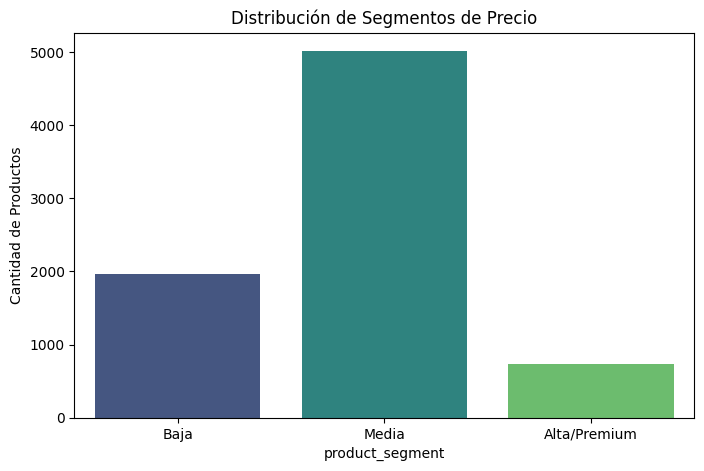

In [150]:
plt.figure(figsize=(8, 5))
sns.countplot(x='product_segment', data=df_uncleaned, palette='viridis', 
              order=['Baja', 'Media', 'Alta/Premium'])
plt.title('Distribución de Segmentos de Precio')
plt.ylabel('Cantidad de Productos')
plt.show()

In [151]:
# 1. Definimos la función de renderizado
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra 
sample_peripherals = df_uncleaned[['product_title', 'product_image_url', 'original_price', 'product_segment', 'product_category']].sample(5)

# 3. Mostramos la tabla corregida
# Cambiamos 'image_url' por 'product_image_url' en el diccionario
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

,product_title,product_image_url,original_price,product_segment,product_category
3133,"Belkin MagSafe-Compatible Charger, 2-in-1 Magnetic Foldable Charger 15W - Qi2-Certified Wireless Charging for Apple iPhone 16, Apple Watch, Samsung Galaxy S25 w/Non-Slip Base, PSU Included - White",,69.99,Media,"Chargers, Adapters & Cables"
6628,"Tripp Lite Keyspan High-Speed USB to Serial Adapter, PC & Mac, USB-A to DB9 RS232 Male, 3 Foot / 0.91 Meter Cable, 3-Year Warranty (USA-19HS)",,49.60,Media,Computer Peripherals
9069,"Rockville RXM-S6 2600W Peak/660W RMS 6-Channel Marine Amplifier, PA Microphone, Waterproof Design, Bass Remote for Boats and Marine Audio",,194.91,Media,"Audio, Sound & Recording Gear"
3847,"Nintendo Replacement Wii Console, White - No Cables Or Accessories (Renewed)",,69.00,Media,Video Game Consoles & Virtual Reality
3836,DURACELL CopperTop Alkaline Batteries with Duralock Power Preserve Technology D 12/Box (MN1300),,24.94,Media,Power & Batteries


#### Normalización de los precios (Tranformación logarítmica)

In [152]:
# 1. Aplicamos la transformación logarítmica
df_uncleaned['log_original_price'] = np.log1p(df_uncleaned['original_price'])

# 2. Verificamos los primeros resultados
print(df_uncleaned[['original_price', 'log_original_price']].head())

    original_price  log_original_price
32          239.99            5.484755
31           42.99            3.783962
29           35.89            3.607941
28           43.89            3.804215
27            9.54            2.355178


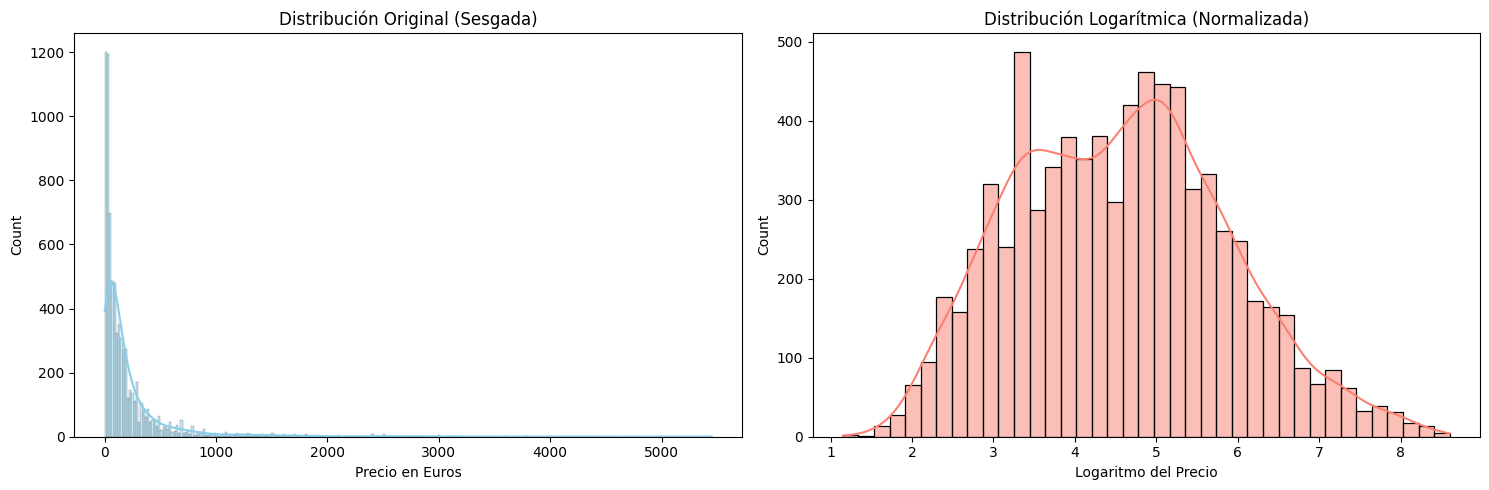

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución Original
sns.histplot(df_uncleaned['original_price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Original (Sesgada)')
axes[0].set_xlabel('Precio en Euros')

# Distribución Logarítmica
sns.histplot(df_uncleaned['log_original_price'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución Logarítmica (Normalizada)')
axes[1].set_xlabel('Logaritmo del Precio')

plt.tight_layout()
plt.show()

### NORMALIZACIÓN DE VENTAS

In [154]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7717 entries, 32 to 42674
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_title             7717 non-null   object 
 1   product_rating            7717 non-null   float64
 2   total_reviews             7717 non-null   float64
 3   purchased_last_month      7717 non-null   Int64  
 4   original_price            7717 non-null   float64
 5   is_sponsored              7717 non-null   int8   
 6   coupon                    7717 non-null   object 
 7   buy_box_availability      7717 non-null   int32  
 8   sustainability_tags       7717 non-null   int32  
 9   product_image_url         7717 non-null   object 
 10  has_coupon                7717 non-null   int32  
 11  discount_percentage       7717 non-null   float64
 12  badge_amazons             7717 non-null   int8   
 13  badge_best_seller         7717 non-null   int8   
 14  badge_ends_

In [ ]:
# 1. Aplicamos la transformación logarítmica
df_uncleaned['log_purchased_last_month'] = np.log1p(df_uncleaned['purchased_last_month'])

# 2. Verificamos los primeros resultados
print(df_uncleaned[['purchased_last_month', 'log_purchased_last_month']].head())

    bought_in_last_month  log_purchased_last_month
32                     0                       0.0
31                     0                       0.0
29                 50000                 10.819798
28                 50000                 10.819798
27                 10000                   9.21044


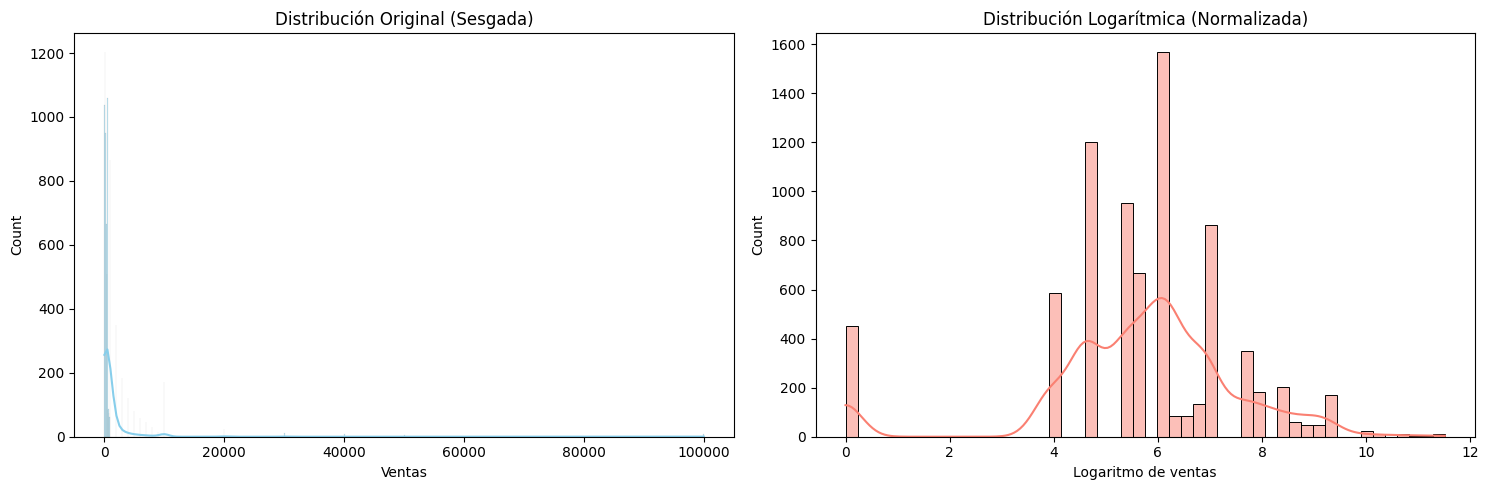

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución Original
sns.histplot(df_uncleaned['purchased_last_month'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Original (Sesgada)')
axes[0].set_xlabel('Ventas')

# Distribución Logarítmica
sns.histplot(df_uncleaned['log_purchased_last_month'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución Logarítmica (Normalizada)')
axes[1].set_xlabel('Logaritmo de ventas')

plt.tight_layout()
plt.show()

Posteriormente, cuando el modelo prediga un valor de 2.3, aplicaremos una funcion exponencial para volver el precio a la realidad

#### One-Hot Encoding para 'product_segment'

In [158]:
# 1. Aplicamos One-Hot Encoding
# 'prefix' añade un nombre a las columnas para saber de dónde vienen
dummies_segment = pd.get_dummies(df_uncleaned['product_segment'], prefix='segment', dtype=int)

# 2. Concatenamos las nuevas columnas al dataframe original
df_uncleaned = pd.concat([df_uncleaned, dummies_segment], axis=1)

# 3. Verificamos cómo han quedado las nuevas columnas
print(df_uncleaned[['product_segment', 'segment_Baja', 'segment_Media', 'segment_Alta/Premium']].head())

   product_segment  segment_Baja  segment_Media  segment_Alta/Premium
32           Media             0              1                     0
31           Media             0              1                     0
29           Media             0              1                     0
28           Media             0              1                     0
27            Baja             1              0                     0


In [159]:
df_uncleaned.head(5)

,product_title,product_rating,total_reviews,purchased_last_month,original_price,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,...,badge_limited_time_deal,badge_no_badge,badge_save_xpct,product_category,log_purchased_last_month,product_segment,log_original_price,segment_Alta/Premium,segment_Baja,segment_Media
32,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358.0,0,239.99,1,No Coupon,1,0,https://m.media-amazon.com/images/I/51vvx1JymA...,...,0,1,0,PC Components,0.0,Media,5.484755,0,0,1
31,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,276.0,0,42.99,1,No Coupon,1,0,https://m.media-amazon.com/images/I/41d4RtiB8E...,...,0,1,0,Storage & Memory Cards,0.0,Media,3.783962,0,0,1
29,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,101072.0,50000,35.89,0,No Coupon,0,1,https://m.media-amazon.com/images/I/71y57XPIia...,...,0,0,0,"Office Supplies, Ink & Toner",10.819798,Media,3.607941,0,0,1
28,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,59092.0,50000,43.89,0,No Coupon,0,0,https://m.media-amazon.com/images/I/51eBahpKda...,...,0,1,0,"Office Supplies, Ink & Toner",10.819798,Media,3.804215,0,0,1
27,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,108926.0,10000,9.54,0,No Coupon,0,0,https://m.media-amazon.com/images/I/41CiQ7hR31...,...,0,0,0,"Audio, Sound & Recording Gear",9.21044,Baja,2.355178,0,1,0


In [161]:
info = info_df(df_uncleaned)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,7717,0,object,7717
1,product_rating,7717,0,float64,31
2,total_reviews,7717,0,float64,3984
3,purchased_last_month,7717,0,Int64,30
4,original_price,7717,0,float64,3061
5,is_sponsored,7717,0,int8,2
6,coupon,7717,0,object,42
7,buy_box_availability,7717,0,int32,2
8,sustainability_tags,7717,0,int32,2
9,product_image_url,7717,0,object,7600


### Drop product_segment

In [3]:
df_uncleaned.drop(columns=['product_segment'], inplace=True)

### NORMALIZAR TOTAL_REVIEWS

In [6]:
# 1. Aplicamos la transformación logarítmica
df_uncleaned['log_total_reviews'] = np.log1p(df_uncleaned['total_reviews'])

# 2. Verificamos los primeros resultados
print(df_uncleaned[['total_reviews', 'log_total_reviews']].head())

   total_reviews  log_total_reviews
0          358.0           5.883322
1          276.0           5.624018
2       101072.0          11.523598
3        59092.0          10.986868
4       108926.0          11.598433


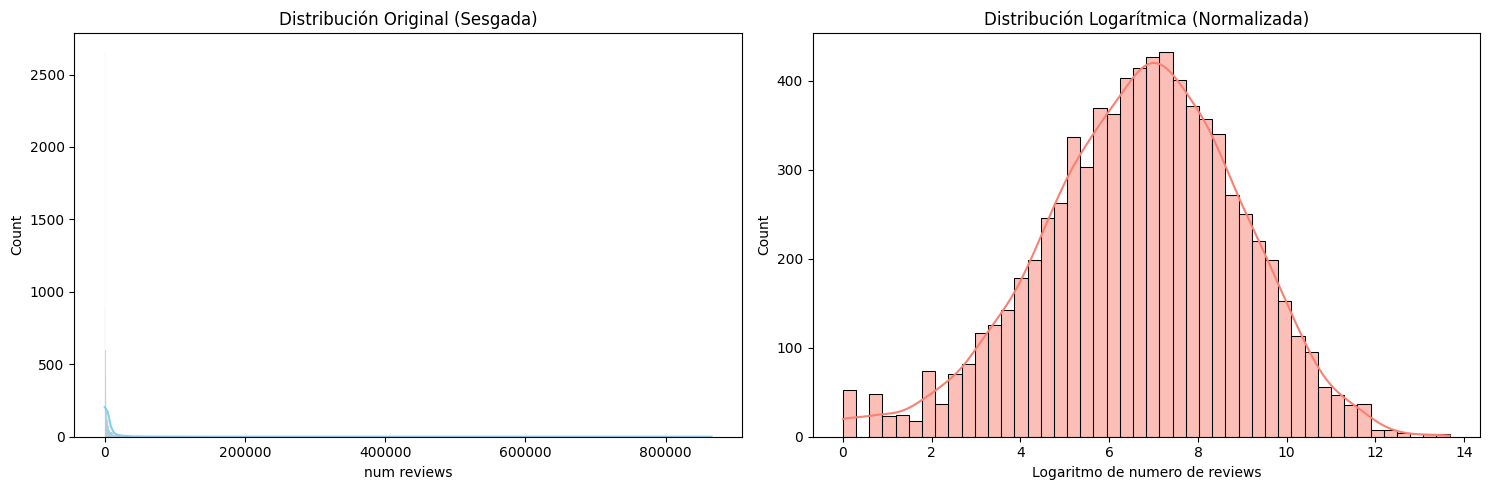

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución Original
sns.histplot(df_uncleaned['total_reviews'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Original (Sesgada)')
axes[0].set_xlabel('num reviews')

# Distribución Logarítmica
sns.histplot(df_uncleaned['log_total_reviews'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución Logarítmica (Normalizada)')
axes[1].set_xlabel('Logaritmo de numero de reviews')

plt.tight_layout()
plt.show()

### Exportación CSV

In [8]:
df_uncleaned.to_csv('../Datasets/amazon_final.csv', index=False)